# IT1244 Group Project: Bank Marketing Campaign Analysis and Prediction

## Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, classification_report, roc_auc_score, roc_curve, auc

from imblearn.pipeline import Pipeline as ImbPipeline

import pickle

## Load dataset and initial view

In [2]:
df_raw = pd.read_csv('dataset.csv')
df_raw

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,0,0,0,telephone,may,mon,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,-1,0,0,telephone,may,mon,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,0,1,0,telephone,may,mon,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,0,0,0,telephone,may,mon,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,0,0,1,telephone,may,mon,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,0,1,0,cellular,nov,fri,334,1,999,0,-1.1,94.767,-50.8,1.028,4963.6,1
41184,46,blue-collar,married,professional.course,0,0,0,cellular,nov,fri,383,1,999,0,-1.1,94.767,-50.8,1.028,4963.6,0
41185,56,retired,married,university.degree,0,1,0,cellular,nov,fri,189,2,999,0,-1.1,94.767,-50.8,1.028,4963.6,0
41186,44,technician,married,professional.course,0,0,0,cellular,nov,fri,442,1,999,0,-1.1,94.767,-50.8,1.028,4963.6,1


## Basic Exploratory Data Analysis (EDA)

In [3]:
##Descriptive Stats

basic_stats = df_raw.describe().T
print(basic_stats)

# 2. Comparison by Class (The most important part for your report)
# We group by the target 'y' to see how the 'average' subscriber differs
# We exclude 'duration' to stay consistent with the 'no-leakage' requirement
num_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
if 'duration' in num_cols: num_cols.remove('duration')

class_comparison = df_raw.groupby('y')[num_cols].mean().T
class_comparison.columns = ['Mean (No)', 'Mean (Yes)']

# Calculate the percentage difference to highlight the strongest predictors
class_comparison['Diff %'] = ((class_comparison['Mean (Yes)'] - class_comparison['Mean (No)']) / class_comparison['Mean (No)']) * 100

print("\n--- Mean Comparison by Target Class ---")
print(class_comparison)

# 3. Variance and Skewness
# High skewness (e.g., in 'campaign') justifies why you might use certain scalers
stats_extra = pd.DataFrame({
    'Variance': df_raw[num_cols].var(),
    'Skewness': df_raw[num_cols].skew()
})

print("\n--- Variance and Skewness ---")
print(stats_extra)

                  count         mean         std       min       25%  \
age             41188.0    40.024060   10.421250    17.000    32.000   
default         41188.0    -0.208653    0.406530    -1.000     0.000   
housing         41188.0     0.499806    0.545967    -1.000     0.000   
loan            41188.0     0.127659    0.399297    -1.000     0.000   
duration        41188.0   258.285010  259.279249     0.000   102.000   
campaign        41188.0     2.567593    2.770014     1.000     1.000   
pdays           41188.0   962.475454  186.910907     0.000   999.000   
previous        41188.0     0.172963    0.494901     0.000     0.000   
emp.var.rate    41188.0     0.081886    1.570960    -3.400    -1.800   
cons.price.idx  41188.0    93.575664    0.578840    92.201    93.075   
cons.conf.idx   41188.0   -40.502600    4.628198   -50.800   -42.700   
euribor3m       41188.0     3.621291    1.734447     0.634     1.344   
nr.employed     41188.0  5167.035911   72.251528  4963.600  5099

Text(0.5, 0, 'Subscription Rate')

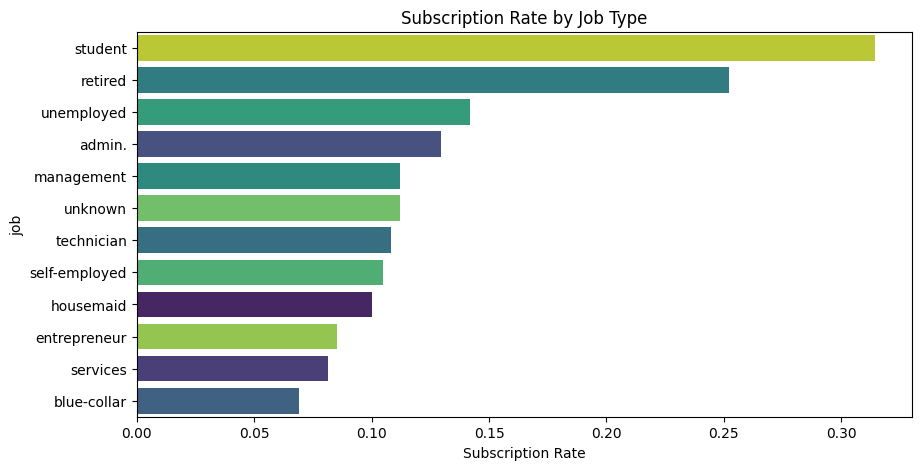

In [4]:
# A. Job Segment
plt.figure(figsize=(10, 5))
job_order = df_raw.groupby('job')['y'].mean().sort_values(ascending=False).index
sns.barplot(x='y', y='job', data=df_raw, order=job_order, errorbar=None, hue = 'job', legend = False,  palette='viridis')
plt.title('Subscription Rate by Job Type')
plt.xlabel('Subscription Rate')

Text(0, 0.5, 'Subscription Rate')

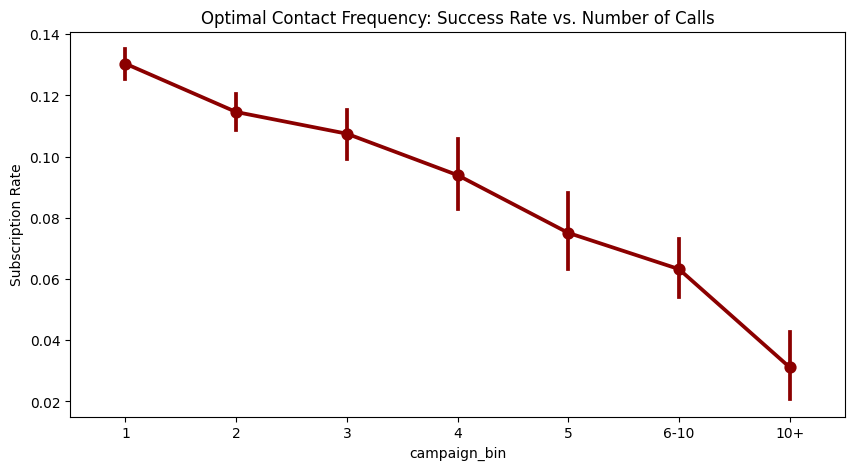

In [5]:
# B. Optimal Campaign Frequency
df_raw['campaign_bin'] = pd.cut(df_raw['campaign'], bins=[0, 1, 2, 3, 4, 5, 10, 50], 
                           labels=['1', '2', '3', '4', '5', '6-10', '10+'])
plt.figure(figsize=(10, 5))
sns.pointplot(x='campaign_bin', y='y', data=df_raw, color='darkred')
plt.title('Optimal Contact Frequency: Success Rate vs. Number of Calls')
plt.ylabel('Subscription Rate')

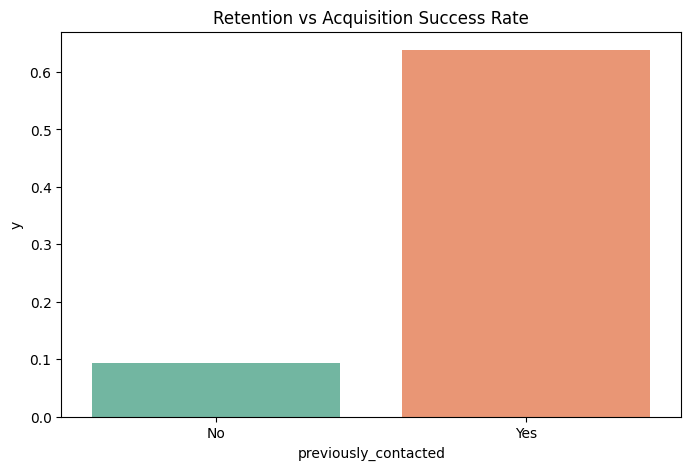

In [6]:
# C. Retention (Previous Success)
df_raw['previously_contacted'] = df_raw['pdays'].apply(lambda x: 'No' if x == 999 else 'Yes') #means cust not retained
plt.figure(figsize=(8, 5))
sns.barplot(x='previously_contacted', y='y', data=df_raw, hue = 'previously_contacted', legend = False, palette='Set2', errorbar=None)
plt.title('Retention vs Acquisition Success Rate')
plt.show()

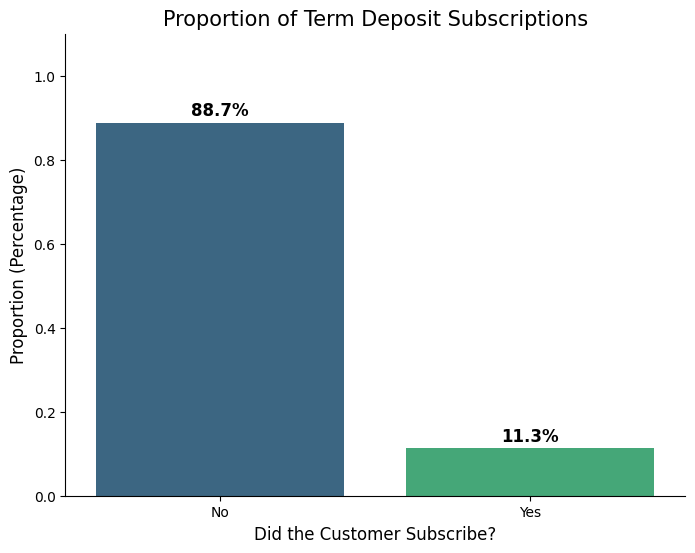

In [7]:
proportions = df_raw['y'].value_counts(normalize=True).reset_index()
proportions.columns = ['Subscribed', 'Proportion']

# Map 0/1 or 'no'/'yes' to readable labels if necessary
proportions['Subscribed'] = proportions['Subscribed'].replace({0: 'No', 1: 'Yes'})

plt.figure(figsize=(8, 6))
ax = sns.barplot(x='Subscribed', y='Proportion', data=proportions, hue = 'Subscribed', legend = False, palette='viridis')

# 3. Add percentage labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()*100:.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=12, fontweight='bold')

plt.title('Proportion of Term Deposit Subscriptions', fontsize=15)
plt.ylabel('Proportion (Percentage)', fontsize=12)
plt.xlabel('Did the Customer Subscribe?', fontsize=12)
plt.ylim(0, 1.1)
sns.despine()
plt.show()

## Model training

In [8]:
df = pd.read_csv('dataset.csv')
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,0,0,0,telephone,may,mon,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,-1,0,0,telephone,may,mon,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,0,1,0,telephone,may,mon,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,0,0,0,telephone,may,mon,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,0,0,1,telephone,may,mon,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,0,1,0,cellular,nov,fri,334,1,999,0,-1.1,94.767,-50.8,1.028,4963.6,1
41184,46,blue-collar,married,professional.course,0,0,0,cellular,nov,fri,383,1,999,0,-1.1,94.767,-50.8,1.028,4963.6,0
41185,56,retired,married,university.degree,0,1,0,cellular,nov,fri,189,2,999,0,-1.1,94.767,-50.8,1.028,4963.6,0
41186,44,technician,married,professional.course,0,0,0,cellular,nov,fri,442,1,999,0,-1.1,94.767,-50.8,1.028,4963.6,1


In [9]:
# Separate Train and Test Datasets
# Select 90% for training, 10% for testing
X = df.copy().drop('y', axis = 1, inplace = False)
y = df.copy()['y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.1, stratify = y , random_state = 1244)

In [10]:
drop_duration = ColumnTransformer(
    transformers = [
        ('drop duration column', 'drop', ['duration'])
    ],
    remainder = 'passthrough',
    verbose_feature_names_out= False).set_output(transform="pandas")

remove_NaN = ColumnTransformer(
    transformers = [
        ('string imputer', SimpleImputer(missing_values = 'unknown', strategy = 'most_frequent'),
         ['job','marital', 'education']),
        ('numerical imputer', SimpleImputer(missing_values = -1, strategy = 'most_frequent'),
         ["default", "housing", "loan"])
    ],
    remainder = 'passthrough',
    verbose_feature_names_out = False).set_output(transform="pandas")

def silhouette_scorer(estimator, X):
    return silhouette_score(X, estimator.predict(X))

class KMeansClustering(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.preprocess_pipe = ColumnTransformer(transformers = [('encode categorical', OneHotEncoder(sparse_output = False),
                                                                  ['job','marital', 'education', 'contact', 'month', 'day_of_week'])],
                                                 remainder = 'passthrough',
                                                 verbose_feature_names_out = False).set_output(transform="pandas")
        self.kmeans_pipe = ImbPipeline([
            ('Standardise', StandardScaler()),
            ('PCA', PCA(n_components = 0.8)),
            ('KMeans', KMeans(random_state = 1244, n_init = 10))
        ])
        self.param_grid = {'KMeans__n_clusters': [2,3,4,5,6,7,8], 'KMeans__init': ['k-means++', 'random']}
        self.kmeans_gridsearch = GridSearchCV(self.kmeans_pipe, self.param_grid, scoring = silhouette_scorer, n_jobs=-1, cv=5)
        self.is_fitted_ = False

    def fit(self, X, y = None):
        km_X = self.preprocess_pipe.fit_transform(X.copy())
        self.kmeans_gridsearch.fit(km_X)
        print(pd.DataFrame(self.kmeans_gridsearch.cv_results_)[['param_KMeans__init', 'param_KMeans__n_clusters', 'mean_test_score']].sort_values('mean_test_score', ascending = False).head(3))
        print(f"Best Parameters: {self.kmeans_gridsearch.best_params_}")
        self.is_fitted_ = True
        return self

    def transform(self, X):
        km_X = self.preprocess_pipe.transform(X.copy())
        X_labelled = X.copy()
        X_labelled['labels'] = self.kmeans_gridsearch.best_estimator_.predict(km_X)
        return X_labelled

KMeans_clusterer = KMeansClustering()

In [11]:
class LogisticRegressionPerCluster(BaseEstimator):
    def __init__(self):
        self.model_pipe = ImbPipeline([
            ('encode_cat', ColumnTransformer(transformers=[('onehot_enc', OneHotEncoder(categories='auto', sparse_output = False),
                                                            ['job', 'marital', 'education', 'contact', 'month', 'day_of_week'])],
                                             remainder='passthrough',
                                             verbose_feature_names_out= False
                                             ).set_output(transform='pandas')),
            ('scale', StandardScaler()),
            ('clf', LogisticRegression(random_state=1244, max_iter=1000, solver = 'saga'))
        ])
        self.param_grid = {'clf__C': [0.01, 0.05, 0.1, 1, 10],
                           'clf__l1_ratio': [0, 0.25, 0.5, 0.75, 1.0],
                           'clf__class_weight': [None, 'balanced'],
                           }
        self.model_gridsearch = GridSearchCV(self.model_pipe, self.param_grid,
                                             cv=5, scoring='roc_auc', n_jobs=-1)
        self.models_ = {}
        self.threshold_range = np.arange(0.1, 1.0, 0.1)
        self.best_thresholds = {}
        self.is_fitted_ = False

    def fit(self, X, y):
        for cluster_id in X['labels'].unique():
            print(f'Fitting for cluster {cluster_id}...')
            X_clustered = X[X['labels'] == cluster_id].copy()
            y_clustered = y[X['labels'] == cluster_id]
            print(f'Proportion of 1s in cluster {cluster_id}: {np.mean(y_clustered)}')
            X_clustered.drop('labels', axis = 1, inplace=True)
            self.model_gridsearch.fit(X_clustered, y_clustered)
            self.models_[cluster_id] = self.model_gridsearch.best_estimator_
            print(pd.DataFrame(self.model_gridsearch.cv_results_)[['param_clf__C', 'param_clf__l1_ratio', 'param_clf__class_weight', 'mean_test_score']].sort_values('mean_test_score', ascending=False).head(3))
            print(f"Best Parameters for cluster {cluster_id}: {self.model_gridsearch.best_params_}")

            y_proba_clustered = self.models_[cluster_id].predict_proba(X_clustered)[:,1]
            f1_scores = [f1_score(y_clustered,
                                  np.where(y_proba_clustered >= threshold, 1,0))
                         for threshold in self.threshold_range]
            self.best_thresholds[cluster_id] = self.threshold_range[np.argmax(f1_scores)]
            print(f"Best threshold selected from cluster {cluster_id}'s F1 Score: {self.best_thresholds[cluster_id]}")

        self.is_fitted_ = True
        return self

    def predict(self, X):
        predictions = np.zeros(X.shape[0])
        for cluster_id, model in self.models_.items():
            X_clustered = X[X['labels'] == cluster_id].copy()
            X_clustered.drop('labels', axis = 1, inplace = True)
            predictions[X['labels'] == cluster_id] = model.predict(X_clustered)
        return predictions

    def predict_proba(self, X):
        probabilities = np.zeros((X.shape[0],2))
        for cluster_id, model in self.models_.items():
            X_clustered = X[X['labels'] == cluster_id].copy()
            X_clustered.drop('labels', axis = 1, inplace = True)
            probabilities[X['labels'] == cluster_id] = model.predict_proba(X_clustered)
        return probabilities

    def predict_from_threshold(self, X):
        predictions = np.zeros(X.shape[0])
        probabilities = self.predict_proba(X)[:,1]
        for cluster_id, threshold in self.best_thresholds.items():
            probabilities_clustered = probabilities[X['labels'] == cluster_id]
            predictions[X['labels'] == cluster_id] = np.where(probabilities_clustered >= threshold, 1, 0)
        return predictions

Logistic_regression = LogisticRegressionPerCluster()

## Model fitting

Uncomment the code cell below if the 'final_model.pkl' file does not exist or you want to retrain the model. Otherwise, the trained model can be accessed in following cells by the .pkl file.

In [12]:
# overall_model_pipe = ImbPipeline([
#     ("Drop 'duration' column", drop_duration),
#     ('Remove NaN', remove_NaN),
#     ('KMeans Clustering', KMeans_clusterer),
#     ('Logistic Regression', Logistic_regression)
# ])
#
# overall_model_pipe.fit(X_train, y_train)
#
# pickle.dump(overall_model_pipe, open('final_model.pkl', 'wb'))

## Model Prediction and Evaluation

Uncomment the code cell below if you want to load own dataset for model prediction and evaluation based on the trained model. Otherwise, the code will run with the existing 'dataset.csv' X_test and y_test.


Replace the file path of own dataset in the first line. Ensure the dataset you load has the same structure as the original provided dataset, especially columns that can have unknown/-1 values. The model expects the same features for preprocessing and model training to work correctly.

In [13]:
# # This cell code is a placeholder for future test set
#
# filepath = 'dataset.csv'
# input_df = pd.read_csv(filepath)
#
# X_test = input_df.copy().drop('y', axis = 1, inplace = False)
# y_test = input_df.copy()['y']

In [14]:
overall_model_pipe = pickle.load(open('final_model.pkl', 'rb'))
y_test_pred = overall_model_pipe.predict_proba(X_test)[:,1]
X_test_transformed = (
    overall_model_pipe.named_steps['KMeans Clustering'].transform(
    overall_model_pipe.named_steps['Remove NaN'].transform(X_test))
)
y_test_pred_custom = overall_model_pipe.named_steps['Logistic Regression'].predict_from_threshold(X_test_transformed)
# Print Evaluation Metrics
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_custom))

print(f"Final Test ROC-AUC: {roc_auc_score(y_test, y_test_pred):.4f}")


Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.93      3655
           1       0.44      0.48      0.46       464

    accuracy                           0.87      4119
   macro avg       0.69      0.70      0.69      4119
weighted avg       0.88      0.87      0.87      4119

Final Test ROC-AUC: 0.7861


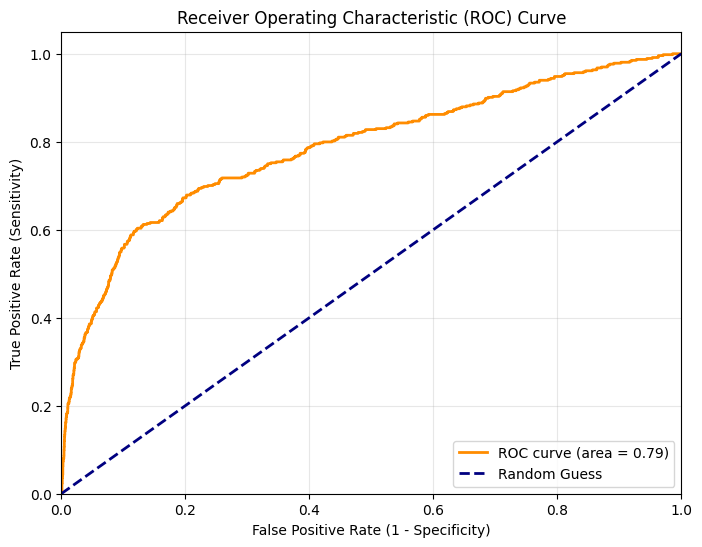

In [15]:
# Compute ROC curve and ROC area
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred)
roc_auc = auc(fpr, tpr)

# Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## Inspect model features and important variables

In [16]:
clusters = pd.DataFrame(
    {'ScaledValue': overall_model_pipe[2].kmeans_gridsearch.best_estimator_[1].inverse_transform(overall_model_pipe[2].kmeans_gridsearch.best_estimator_[2].cluster_centers_)[0],
     'OriginalValue': overall_model_pipe[2].kmeans_gridsearch.best_estimator_[0].inverse_transform(overall_model_pipe[2].kmeans_gridsearch.best_estimator_[1].inverse_transform(overall_model_pipe[2].kmeans_gridsearch.best_estimator_[2].cluster_centers_)[0].reshape(1,-1)).flatten()
     },
    index = overall_model_pipe[2].preprocess_pipe.transform(overall_model_pipe[:2].transform(X_train)).columns).join(
    pd.DataFrame(
    {'ScaledValue': overall_model_pipe[2].kmeans_gridsearch.best_estimator_[1].inverse_transform(overall_model_pipe[2].kmeans_gridsearch.best_estimator_[2].cluster_centers_)[1],
     'OriginalValue': overall_model_pipe[2].kmeans_gridsearch.best_estimator_[0].inverse_transform(overall_model_pipe[2].kmeans_gridsearch.best_estimator_[1].inverse_transform(overall_model_pipe[2].kmeans_gridsearch.best_estimator_[2].cluster_centers_)[1].reshape(1,-1)).flatten()},
    index = overall_model_pipe[2].preprocess_pipe.transform(overall_model_pipe[:2].transform(X_train)).columns),
    lsuffix = ' 0', rsuffix = ' 1'
)
clusters['ScaledDiff'] = np.abs(clusters['ScaledValue 0'] - clusters['ScaledValue 1'])
clusters.sort_values(by = 'ScaledDiff', ascending = False).head(8).sort_values(by = 'ScaledValue 0', ascending = False)

,ScaledValue 0,OriginalValue 0,ScaledValue 1,OriginalValue 1,ScaledDiff
euribor3m,0.662916,4.771949,-1.352307,1.277296,2.015222
emp.var.rate,0.639461,1.087394,-1.304460,-1.969660,1.943921
nr.employed,0.622697,5212.040300,-1.270262,5075.398978,1.892959
cons.price.idx,0.458865,93.840947,-0.936057,93.033027,1.394922
contact_telephone,0.270298,0.495646,-0.551390,0.099951,0.821688
contact_cellular,-0.270298,0.504354,0.551390,0.900049,0.821688
previous,-0.311959,0.018303,0.636378,0.488249,0.948337
month_apr,-0.324446,-0.015539,0.661850,0.225318,0.986297


In [17]:
features_summary_0 = pd.DataFrame({
    'Feature': overall_model_pipe.named_steps['Logistic Regression'].models_[0].named_steps['encode_cat'].get_feature_names_out(),
    'Coefficients': overall_model_pipe.named_steps['Logistic Regression'].models_[0].named_steps['clf'].coef_[0]
})
features_summary_0.sort_values(by='Coefficients', key=abs, ascending=False).head(5)

,Feature,Coefficients
28,month_oct,0.167770
26,month_may,-0.109132
22,contact_telephone,-0.064130
21,contact_cellular,0.064130
24,month_jul,0.057909


In [18]:
features_summary_1 = pd.DataFrame({
    'Feature': overall_model_pipe.named_steps['Logistic Regression'].models_[1].named_steps['encode_cat'].get_feature_names_out(),
    'Coefficients': overall_model_pipe.named_steps['Logistic Regression'].models_[1].named_steps['clf'].coef_[0]
})
features_summary_1.sort_values(by='Coefficients', key=abs, ascending=False).head(5)

,Feature,Coefficients
46,cons.price.idx,1.429511
49,nr.employed,1.049923
45,emp.var.rate,-0.803807
43,pdays,-0.565229
28,month_mar,0.370256
